# PyAstroPol : A Python package for instrumental polarization analysis

### Hemanth Pruthvi <br> Thüringer Landesternwarte <br> Tautenburg, Germany

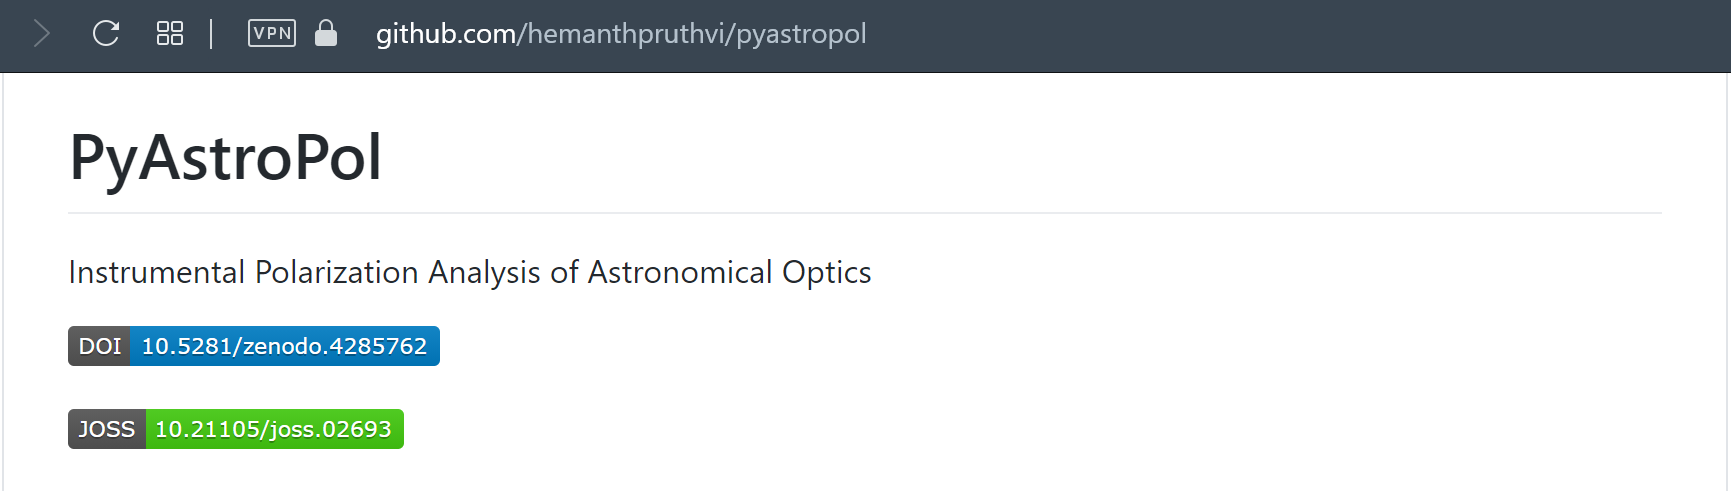

# What? 

# Light and Polarization
![](Picture2.png)

# Quantitative description of polarization

## Stokes vector
$$ S = \begin{bmatrix} I \\ Q \\ U \\ V \end{bmatrix} = 
\begin{bmatrix} <E_x.E_x^*> + <E_y.E_y^*> \\
<E_x.E_x^*> - <E_y.E_y^*> \\ 
<E_x^*.E_y> + <E_x.E_y^*> \\
j(<E_x.E_y^*> - <E_x^*.E_y>) \end{bmatrix} $$

## Mueller matrix

$$ M = \begin{bmatrix} 
I\rightarrow I & I\rightarrow Q & I\rightarrow U & I\rightarrow V \\
Q\rightarrow I & Q\rightarrow Q & Q\rightarrow U & Q\rightarrow V \\
U\rightarrow I & U\rightarrow Q & U\rightarrow U & U\rightarrow V \\
V\rightarrow I & V\rightarrow Q & V\rightarrow U & V\rightarrow V \\
\end{bmatrix} $$

![](Picture3.png)

# Instrumental polarization
![](Picture1.png)

# Why?

## The case of Kodaikanal Tower-tunnel Telescope

![](Picture4.png)

## The case of Vacuum Tower Telescope
![](Picture5.png)

## Python

- Popular scientific programming language
- Object oriented
- Easy development
- Open-source & plenty open-source suport

# How?

## Entities used in optical modelling -- Classes (Objects)
- Surface : basic media interface
- Material : basic materials
- Coating : multi-layered coating
- Source : basic source of light
- Elements : contains other aforementioned classes

## Framework
- Polarized ray propagation of electric field
- Coherent addition of electric fields of the rays at the end of propagation

# A simple Lens

In [1]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import PyAstroPol as pap
import numpy as np
pap.roundOffDisplay(5)
#
Source_analysis = pap.Source(10000, Clear=40)                   # Source for ray analysis
Source_analysis.translateOrigin(z=-100)                         # Adjust source position
#
Source_display = pap.Source(20, Clear=40)                       # Source for ray display
Source_display.translateOrigin(z=-100)                          # Adjust source (display) position
#
Lens_1 = pap.UncoatedLens(50, 10, R1=200, R2=-200, n='N-BK7')   # Lens
#
Detector_1 = pap.Detector(20)                                   # Detector
Detector_1.translateOrigin(z=200.3)                             # Adjust detector position

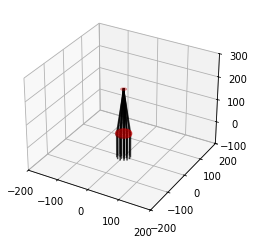

System Mueller matrix is : 
 [[ 1.00000  0.00000  0.00000  0.00000]
 [ 0.00000  1.00000  0.00000  0.00000]
 [-0.00000  0.00000  1.00000 -0.00000]
 [ 0.00000  0.00000 -0.00000  1.00000]]
Throughput is:  0.9219384171068948


In [2]:
Sys = pap.System(Source_analysis, [Lens_1], 
             Detector_1, dRays=Source_display)                  # Complete optical system
Sys.propagateRays()                                             # Propagate rays through system
Fig = plt.figure()                                             
Ax = Fig.add_subplot(111, projection='3d')
Sys.draw(Ax)                                                    # Draw optical system
pap.adjustAspect(Ax, 400, z=100)                                # Adjust 3D space
plt.show()
MM, Tra = Sys.getSystemMuellerMatrix()                          # Optical system's Mueller matrix
print('System Mueller matrix is : \n', MM)
print('Throughput is: ', Tra)

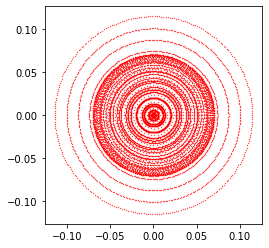

In [3]:
Fig = plt.figure()
Ax = Fig.add_subplot(111, aspect='equal')                       
Sys.drawSpotDiagram(Ax, s=0.1, color='r')                       # Draw spot diagram
plt.show()

# Two 'crossed' mirrors

In [4]:
S = pap.Source(100, Clear=100)                      # Source for ray analysis
Sd = pap.Source(20, Clear=100)                      # Source for ray analysis
S.Wavelength = 0.854
Sd.Wavelength = 0.854
#
M1 = pap.Surface(200, Mirror=True, n2='Al')         # First mirror
M1.rotateAboutX(45)                                 # Fold the mirror
M1.translateOrigin(z=1000)                          # Move the mirror
#
M2 = pap.Surface(200, Mirror=True, n2='Al')         # Second mirror
M2.rotateAboutX(90)                                 # Rotate the mirror
M2.rotateAboutZ(45)                                 # Fold the mirror
M2.translateOrigin(y=1000, z=1000)                  # Move the mirror
#
D = pap.Detector(150)                               # Detector
D.rotateAboutY(90)                                  # Rotate the detector
D.translateOrigin(x=1000, y=1000, z=1000)           # Move the detector
#
D2 = pap.Detector(150)
D2.rotateAboutX(90)                                 # Rotate the detector
D2.translateOrigin(y=1000, z=1000)                  # Move the detector
#
Sys = pap.System(S, [M1, M2], D, dRays=Sd)          # Complete optical system
Sys.propagateRays()                                 # Propagate rays through system
#

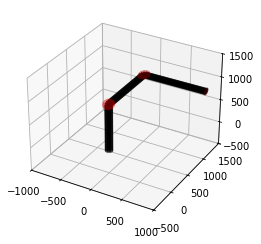

System Mueller matrix is : 
 [[ 1.00000  0.00000  0.00000  0.00000]
 [ 0.00000  1.00000 -0.00000  0.00000]
 [ 0.00000  0.00000  1.00000  0.00000]
 [-0.00000 -0.00000  0.00000  1.00000]]
Throughput is:  0.726425294423879


In [5]:
Fig = plt.figure(); Ax = Fig.add_subplot(111, projection='3d')
Sys.draw(Ax); pap.adjustAspect(Ax, 2000, y=500, z=500); plt.show()          
MM, Tra = Sys.getSystemMuellerMatrix()             
print('System Mueller matrix is : \n', MM); print('Throughput is: ', Tra)

# Off-axis parabola

In [6]:
S = pap.Source(10000, Clear=45)                                         # Source for ray analysis
S.rotateAboutX(180.0)                                                   # 
S.translateOrigin(z=20000.0)                                            # Adjust source position
#
Sd = pap.Source(20, Clear=100.0)                                        # Source for ray display
Sd.rotateAboutX(180.0)                                                  # 
Sd.translateOrigin(z=500.0)                                             # Adjust source position
#
M1 = pap.Surface(100.0, R=1000.0, K=-1.0, Mirror=True, n2=1.1+6.8j, 
             OffAxis=True, OffAxDist=100, OffAxAz=0.0)
#
D = pap.Detector(20)                                                    # Detector
D.translateOrigin(x=-100.0, z=495)                                      # Adjust detector position
#
Sys = pap.System(S, [M1], D, dRays=Sd)                                  # Complete optical system
Sys.propagateRays()                                                     # Propagate rays through system

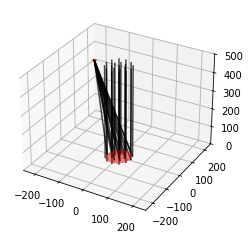

System Mueller matrix is : 
 [[ 1.00000 -0.00049  0.00000  0.00000]
 [-0.00049  1.00000  0.00000  0.00000]
 [-0.00000  0.00000 -1.00000  0.00300]
 [-0.00000  0.00000 -0.00300 -1.00000]]
Throughput is:  0.866949458514975


In [7]:
Fig = plt.figure(); Ax = Fig.add_subplot(111, projection='3d')
Sys.draw(Ax); pap.adjustAspect(Ax, 500, z=250); plt.show()
MM, Tra = Sys.getSystemMuellerMatrix()                                  
print('System Mueller matrix is : \n', MM); print('Throughput is: ', Tra)

# Cassegrain telescope

In [8]:
S = pap.Source(10000, Clear=180)                                    # Source for ray analysis
Sd = pap.Source(20, Clear=180)                                      # Source for ray display
#
M1 = pap.Surface(200, R=-2000, K=-1.0, 
             Mirror=True, n2=1.1+6.8j, iDia=40)                     # Primary mirror with hole
M1.translateOrigin(z=1000)
#
M2 = pap.Surface(100, R=-500, K=-1.01,
             Mirror=True, n2=1.1+6.8j)                              # Secondary mirror with hole
M2.translateOrigin(z=200)
#
D = pap.Detector(10)                                                # Detector
D.translateOrigin(z=1200)                                           # Adjust the position
#
Sys = pap.System(S, [M1, M2], D, dRays=Sd)                          # Complete optical system
Sys.propagateRays()

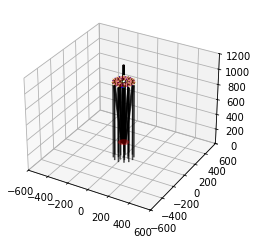

System Mueller matrix is : 
 [[ 1.00000  0.00000  0.00000  0.00000]
 [ 0.00000  1.00000 -0.00000 -0.00000]
 [-0.00000  0.00000  1.00000  0.00000]
 [-0.00000 -0.00000 -0.00000  1.00000]]
Throughput is:  0.7545698896027909


In [9]:
Fig = plt.figure(); Ax = Fig.add_subplot(111, projection='3d')
Sys.draw(Ax); Sys.Components[0].drawPolarizationDirection(Ax, 10); 
pap.adjustAspect(Ax, 1200, z=600); plt.show()
MM, Tra = Sys.getSystemMuellerMatrix()
print('System Mueller matrix is : \n', MM); print('Throughput is: ', Tra)

# Astronomical telescope

In [10]:
import copy as cp
Systems = []
for i in np.linspace(-60,60,5):                                         # Change Hour Angle 
    S = pap.AstroSource(10, Clear=180, Dec=30.0, HA=i, Lat=30.0)        # Astronomical source
    #
    M1 = pap.Surface(200, R=-2000, Mirror=True, n2=1.1+6.8j, iDia=40)   # Primary mirror with hole
    M1.translateOrigin(z=400)                                                       
    M1.rotateAboutY(S.ThetaY)                                           # Adjust orientation to source
    M1.rotateAboutX(S.ThetaX)
    #
    M2 = pap.Surface(100, R=-500, Mirror=True, n2=1.1+6.8j)             # Secondary mirror with hole
    M2.translateOrigin(z=-400)
    M2.rotateAboutY(S.ThetaY)                                           # Adjust orientation to source
    M2.rotateAboutX(S.ThetaX)
    #       
    D = pap.Detector(50)                                                # Usual detector
    D.translateOrigin(z=520)
    D.rotateAboutY(S.ThetaY)                                            # Adjust orientation to source
    D.rotateAboutX(S.ThetaX)
    #
    Sys = pap.System(S, [M1, M2], D)
    Sys.propagateRays()
    Systems.append(cp.deepcopy(Sys)) 

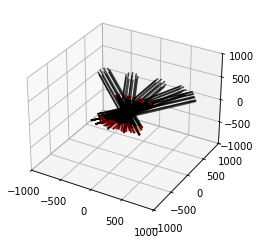

In [11]:
Fig = plt.figure()                                             
Ax = Fig.add_subplot(111, projection='3d')
for Sys in Systems:
    Sys.draw(Ax)
    pap.adjustAspect(Ax, 2000.0)

# KTT Coelostat

In [12]:
class KTTCoelostat(pap.System):
    def __init__(self, Sun, Sun_disp):
        #
        self.Sun = Sun
        Dec = np.radians(self.Sun.Declination)
        HA = np.radians(self.Sun.HourAngle)
        Lat = np.radians(self.Sun.Latitude)
        PolarAxis = np.array([0, np.sin(Lat), np.cos(Lat)])
        self.PolarAxis = PolarAxis
        #
        self.Dist_EW = 830.0  # East-West distance
        self.Dist_ZN = 740.0  # North-South distance
        #
        A = -np.nan_to_num(np.abs(HA)/HA, nan=-1.0)*self.Dist_EW
        B = self.Dist_ZN
        SunPos = np.array([np.sin(HA)*np.cos(Dec), 
                           np.cos(HA)*np.cos(Dec)*np.cos(Lat) + np.sin(Dec)*np.sin(Lat), 
                           -np.cos(HA)*np.cos(Dec)*np.sin(Lat) + np.sin(Dec)*np.cos(Lat)])
        #
        TEMP = np.dot(SunPos, PolarAxis)
        a = TEMP**2-PolarAxis[2]**2
        b = -2*B*PolarAxis[1]*PolarAxis[2]
        c = (A**2+B**2)*TEMP**2 - B**2*PolarAxis[1]**2
        if (a == 0):
            C = -c/b
        else:
            C = (-b + np.nan_to_num(np.abs(Dec)/Dec, nan=1.0)*np.nan_to_num(np.sqrt(b**2-4*a*c)))/2.0/a
        self.Dist_NS = np.abs(C)
        #
        self.Center1 = np.array([-A, 0.0, -C])
        self.Center2 = np.array([0.0, B, 0.0])
        #
        self.Incidence1 = -SunPos
        self.Reflection1 = np.array([A, B, C])/np.linalg.norm(np.array([A, B, C]))
        self.Normal1 = (self.Reflection1-self.Incidence1)/np.linalg.norm(self.Reflection1-self.Incidence1)
        self.Incidence2 = self.Reflection1
        self.Reflection2 = np.array([0.0, -1.0, 0.0])
        self.Normal2 = (self.Reflection2-self.Incidence2)/np.linalg.norm(self.Reflection2-self.Incidence2)
        #
        self.Sun.makeOrigin(self.Center1-self.Sun.Distance*self.Incidence1)
        Sun_disp.makeOrigin(self.Center1-self.Sun.Distance*self.Incidence1)
        #
        C12 = pap.Coating([2.16-7.18j, 1.67], [0.100, 0.00])
        self.M1 = pap.Surface(600, Mirror=True, n2=2.16-7.18j)
        self.M1.pointToDirection(self.Normal1)
        self.M1.makeOrigin(self.Center1)
        # self.M1.Coating = C12
        #
        self.M2 = pap.Surface(600, Mirror=True, n2=2.16-7.18j)
        self.M2.pointToDirection(self.Normal2)
        self.M2.makeOrigin(self.Center2)
        # self.M2.Coating = C12
        #
        self.Window = pap.Detector(500.0)
        self.Window.rotateAboutX(90.0)
        pap.System.__init__(self, self.Sun, [self.M1, self.M2], self.Window, dRays=Sun_disp)
        return
Sun = pap.AstroSource(10000, Clear=300, Dec=6.0, HA=21.0, Lat=10.23, Dist=5000.0)       # Position of the Sun
Sun_disp = pap.AstroSource(20, Clear=300, Dec=6.0, HA=21.0, Lat=10.23, Dist=5000.0)     # Source for display
Coel = KTTCoelostat(Sun, Sun_disp)                                                      # Coelostat configuration
Coel.propagateRays() 

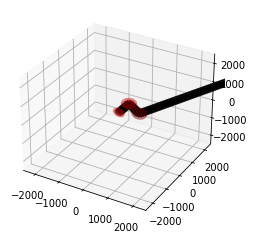

Mueller matrix is : 
 [[ 1.00000 -0.03828 -0.02112 -0.00051]
 [-0.04284  0.76159  0.64734  0.02923]
 [ 0.00872 -0.64387  0.75048  0.14270]
 [-0.00050  0.07046 -0.12749  0.98837]]
Throughput is :  0.7371365125883451


In [13]:
Fig = plt.figure(); Ax = Fig.add_subplot(111, projection='3d')
Coel.draw(Ax); pap.adjustAspect(Ax, 5000.0); plt.show()
MM, Tra = Coel.getSystemMuellerMatrix()
print('Mueller matrix is : \n', MM); print('Throughput is : ', Tra)

# In conclusion -

- PyAstroPol is targeted at a number of applications in astronomy, for instrumental polarization modelling.
- Propagation uses the ray treatment (geometric optics)
- Limited wave optics behaviour is also implemented: 2x2 matrices for coatings and 4x4 matrices for anisotropic interfaces 
